In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw, DataStructs
import json
from chemFilters.img_render import MolGridPlotter


def smis_to_fig(smiles: list, legends: list = None, molsPerRow=None):
    mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    if legends is None:
        legends = ["" for _ in range(len(smiles))]
    if molsPerRow is None:
        molsPerRow = len(mols)
    img = Draw.MolsToGridImage(
        mols, subImgSize=(200, 200), legends=legends, molsPerRow=molsPerRow
    )
    return img

/tmp/ipykernel_1062271/1891006544.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
[15:50:34] Initializing Normalizer
/home/david/micromamba/envs/unichem/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


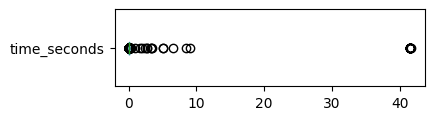

In [3]:
pd.read_csv("jump_SW_time.csv").plot.box(vert=False)
fig = plt.gcf()
fig.set_size_inches(4, 1)

# Parse nohup files

In [4]:
failed_pat = re.compile(r"Query\ssubmission\sfailed")
retries_pat = re.compile(r"An\serror\soccurred")
startline = re.compile(r"\s*\d+\%")

failed_queries = []
max_retries_queries = []

# get the failed queries
outfile = Path("xxx_small_world_nohup.out")
with outfile.open() as f:
    for line in f:
        if not startline.search(line):
            continue
        if failed_pat.search(line):
            failed_queries.append(line.strip())
            failed_queries[-1] += next(f).strip()
        if retries_pat.search(line):
            max_retries_queries.append(line.strip())
            max_retries_queries[-1] += next(f).strip()

In [5]:
failed_queries_idxs = [
    int(line.split("/")[0].split(" ")[-1]) for line in failed_queries
]
max_retries_queries_idxs = [
    int(line.split("/")[0].split(" ")[-1]) for line in max_retries_queries
]

In [6]:
# TODO: investigate these...
failed_queries_idxs

[698,
 1339,
 1510,
 1669,
 2029,
 2196,
 8013,
 8631,
 9265,
 9576,
 10315,
 12290,
 12610,
 13794,
 14648,
 15067,
 15987,
 16322,
 16969,
 17456,
 17837,
 20750,
 21492,
 21635,
 21701,
 23092,
 23447,
 23676,
 24654,
 25000,
 25021,
 25556,
 26891,
 27350,
 27786,
 28562,
 28868,
 29100,
 29235,
 30889,
 31075,
 31362,
 32007,
 34149,
 35877,
 37122,
 37543,
 39363,
 41614,
 43018,
 44867,
 45002,
 45295,
 45863,
 46024,
 47256,
 47432,
 47905,
 48111,
 49429,
 49699,
 49735,
 49869,
 50058,
 50882,
 51739,
 52121,
 52482,
 52653,
 52852,
 53231,
 53966,
 54099,
 54703,
 54879,
 55314,
 55870,
 57794,
 58619,
 58623,
 59166,
 59793,
 60204,
 60293,
 60779,
 61780,
 62341,
 62591,
 62753,
 63529,
 66458,
 67382,
 69422,
 72226,
 73367,
 73763,
 74735,
 75976,
 76776,
 76884,
 77128,
 77757,
 79102,
 79753,
 80106,
 80485,
 80660,
 80723,
 80917,
 81363,
 81972,
 82575,
 84034,
 84088,
 84996,
 85066,
 85680,
 85876,
 87279,
 88193,
 88659,
 90592,
 91729,
 92121,
 92609,
 92660,
 93

# Investigate failed queries...

In [7]:
chemid_dict = json.loads(Path("jump_chemSmiSW_chembl_ids.json").read_text())
smi_dict = json.loads(Path("jump_chemSmiSW_smiles.json").read_text())

meta_col = "Metadata_JCP2022"
# smiles_col = "Standardized_SMILES"
smiles_col = "chembl_not_iso_smiles"

query_smis = (
    pd.read_csv("JUMPCP_compounds_processed.csv.gz", usecols=[meta_col, smiles_col])
    .set_index(meta_col)[smiles_col]
    .to_dict()
)

In [8]:
jump_ids = list(query_smis.keys())
fail_q_ids = np.take(jump_ids, failed_queries_idxs)
maxretry_q_ids = np.take(jump_ids, max_retries_queries_idxs)

grid_plotter = MolGridPlotter(
    from_smi=True, n_jobs=1, unspecified_stereo_unknown=True, size=(500, 500)
)
print("Failed due to max retries: ", len(maxretry_q_ids))
print("Failed due to other reasons: ", len(fail_q_ids))

Failed due to max retries:  18
Failed due to other reasons:  156


## Investigating the failed queries

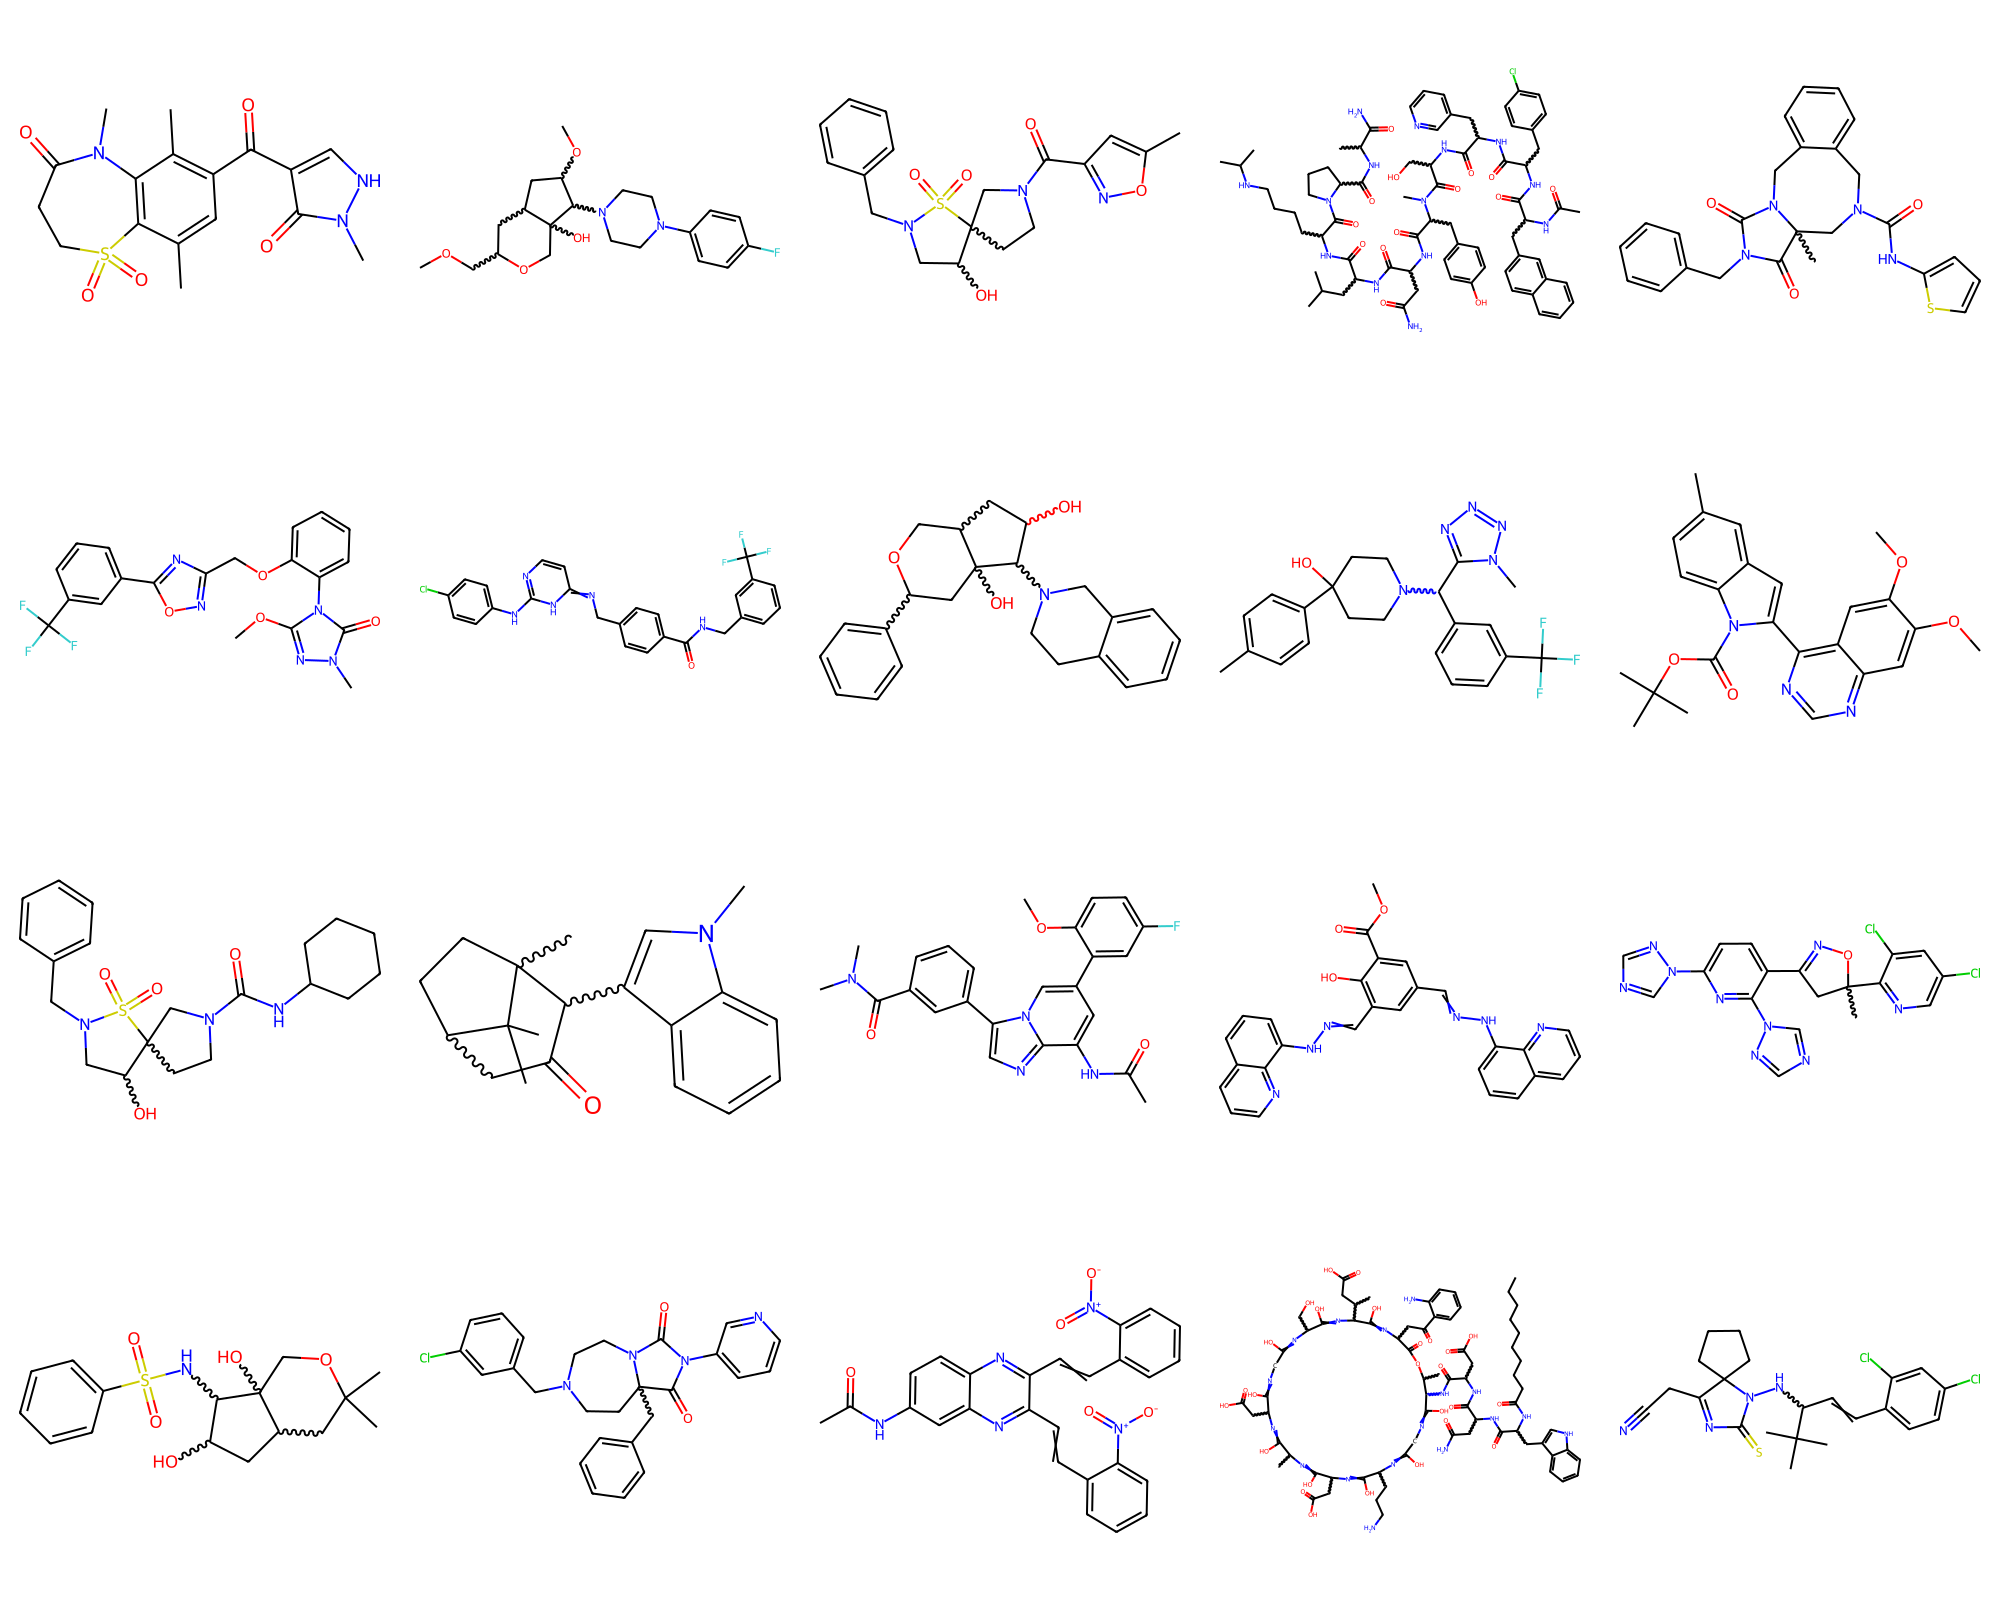

In [9]:
grid_plotter = MolGridPlotter(
    from_smi=True, n_jobs=1, unspecified_stereo_unknown=True, size=(400, 400)
)
smiles = [query_smis[qid] for qid in fail_q_ids[:20]]
grid_plotter.mol_grid_png(
    mols=smiles,
    n_cols=5,
)

In [33]:
smiles[:20]

['Cc1cc(C(=O)c2c[nH]n(C)c2=O)c(C)c2c1S(=O)(=O)CCC(=O)N2C',
 'COCC1CC2CC(OC)C(N3CCN(c4ccc(F)cc4)CC3)C2(O)CO1',
 'Cc1cc(C(=O)N2CCC3(C2)C(O)CN(Cc2ccccc2)S3(=O)=O)no1',
 'CC(=O)NC(Cc1ccc2ccccc2c1)C(=O)NC(Cc1ccc(Cl)cc1)C(=O)NC(Cc1cccnc1)C(=O)NC(CO)C(=O)N(C)C(Cc1ccc(O)cc1)C(=O)NC(CC(N)=O)C(=O)NC(CC(C)C)C(=O)NC(CCCCNC(C)C)C(=O)N1CCCC1C(=O)NC(C)C(N)=O',
 'CC12CN(C(=O)Nc3cccs3)Cc3ccccc3CN1C(=O)N(Cc1ccccc1)C2=O',
 'COc1nn(C)c(=O)n1-c1ccccc1OCc1noc(-c2cccc(C(F)(F)F)c2)n1',
 'O=C(NCc1cccc(C(F)(F)F)c1)c1ccc(CN=c2ccnc(Nc3ccc(Cl)cc3)[nH]2)cc1',
 'OC1CC2COC(c3ccccc3)CC2(O)C1N1CCc2ccccc2C1',
 'Cc1ccc(C2(O)CCN(C(c3cccc(C(F)(F)F)c3)c3nnnn3C)CC2)cc1',
 'COc1cc2ncnc(-c3cc4cc(C)ccc4n3C(=O)OC(C)(C)C)c2cc1OC',
 'O=C(NC1CCCCC1)N1CCC2(C1)C(O)CN(Cc1ccccc1)S2(=O)=O',
 'Cn1cc(C2C(=O)CC3CCC2(C)C3(C)C)c2ccccc21',
 'COc1ccc(F)cc1-c1cc(NC(C)=O)c2ncc(-c3cccc(C(=O)N(C)C)c3)n2c1',
 'COC(=O)c1cc(C=NNc2cccc3cccnc23)cc(C=NNc2cccc3cccnc23)c1O',
 'CC1(c2ncc(Cl)cc2Cl)CC(c2ccc(-n3cncn3)nc2-n2cncn2)=NO1',
 'CC1(C)CC2CC(O)C(NS(=O

In [10]:
from smallworld_api import SmallWorld

sw = SmallWorld()
db = sw.chembl_dataset
sw.configure_logger(level="DEBUG")

default_submission = {
    "sdist": 12,  # maximum scored distance; will limit the search according to the `scores`
    "dist": 8,  # maximum anonymous (topology) distance; will limit the search to [tdn, tup, rdn, rup, ldn, lup]=dist
    "tdn": 6,  # number of terminal down (tdn) edits
    "tup": 6,  # number of terminal up (tup) edits
    "rdn": 6,  # number of ring down (rdn) edits
    "rup": 2,  # number of ring up (rup) edits
    "ldn": 2,  # number of linker down (ldn) edits
    "lup": 2,  # number of linker up (lup) edits
    "maj": 6,  # number of major element transmutations
    "min": 6,  # number of minor element transmutations
    "sub": 6,  # number of substitutions (heavy degree change)
    # "scores": "Atom Alignment,ECFP4,Daylight",
    "scores": "Atom Alignment,ECFP4,Daylight",
}

search_params = {
    "db": db,
    "dist": 0,  # This limits the search to sum([tdn, tup, rdn, rup, ldn, lup]) = 0
    "sdist": 1,  # defined restrictions already stric enough so we can allow scoring distances to be greater
    "length": 5,  # results will be always less than 30
    "maj": 0,  #  no major element transmutations
    "min": 0,  #  no minor element transmutations
    "sub": 0,  #  no heavy degree changes (Hydrogen substitution)
}

search_params = {**sw.default_submission, **search_params}
for smi in smiles[:5]:
    results: pd.DataFrame = sw.search(smi, **search_params)
    if not results.empty:
        print(f"YO SOMETHING WORKED HERE")

2024-03-20 11:59:44 | INFO | Attempting request to URL:
https://smallworld.lacdr.leidenuniv.nl/smallworld/search/view?smi=Cc1cc%28C%28%3DO%29c2c%5BnH%5Dn%28C%29c2%3DO%29c%28C%29c2c1S%28%3DO%29%28%3DO%29CCC%28%3DO%29N2C&db=chembl_31.anon&sdist=1&dist=0&tdn=6&tup=6&rdn=6&rup=2&ldn=2&lup=2&maj=0&min=0&sub=0&scores=Atom+Alignment%2CECFP4%2CDaylight&length=5
2024-03-20 11:59:44 | INFO | Request successful, Time: 11:59:44.247905, Response code: 200
2024-03-20 11:59:44 | INFO | Successful URL: https://smallworld.lacdr.leidenuniv.nl/smallworld/search/view?smi=Cc1cc%28C%28%3DO%29c2c%5BnH%5Dn%28C%29c2%3DO%29c%28C%29c2c1S%28%3DO%29%28%3DO%29CCC%28%3DO%29N2C&db=chembl_31.anon&sdist=1&dist=0&tdn=6&tup=6&rdn=6&rup=2&ldn=2&lup=2&maj=0&min=0&sub=0&scores=Atom+Alignment%2CECFP4%2CDaylight&length=5
2024-03-20 11:59:44 | ERROR | Query submission failed!!
2024-03-20 11:59:44 | ERROR | Reply status: {'dist': 0, 'state': 'ERROR', 'restarts': 1, 'nodeHits': 0, 'nodeVisit': 0, 'edgeVisit': 0, 'elapTime': 0, '

## Investigating the max_retries_queries

In [11]:
grid_plotter = MolGridPlotter(
    from_smi=True, n_jobs=1, unspecified_stereo_unknown=True, size=(500, 500)
)

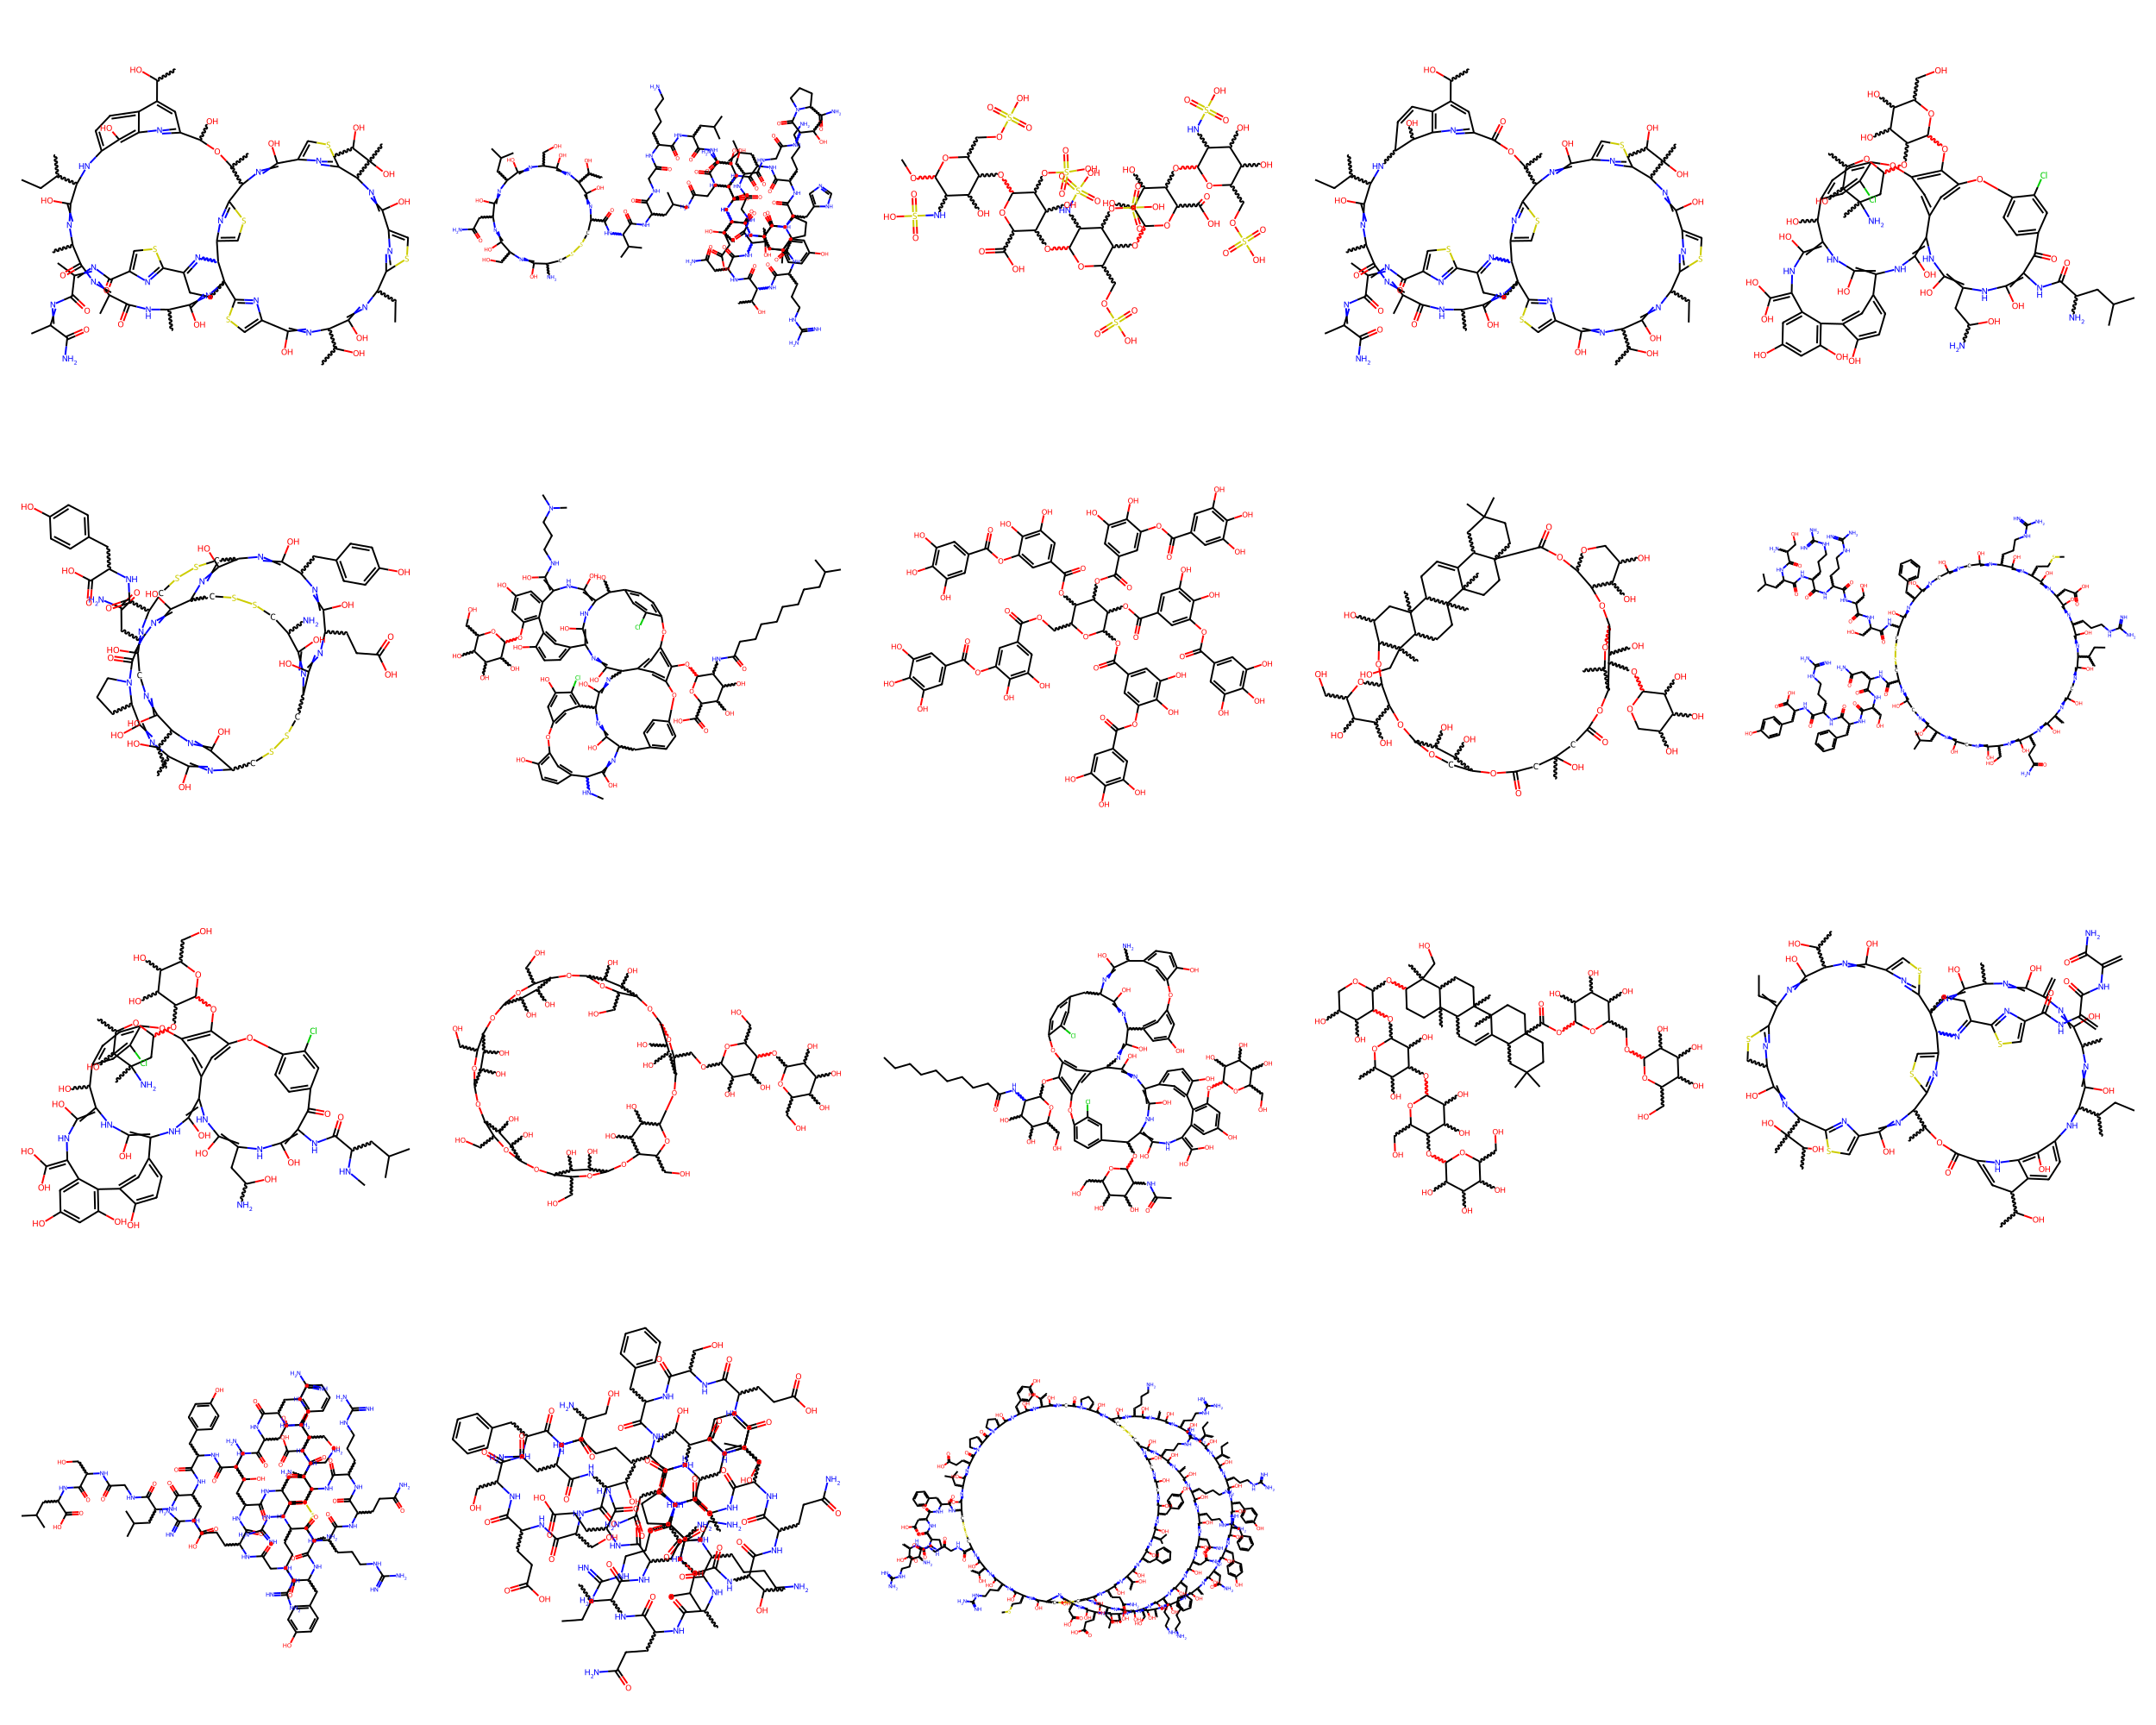

In [12]:
smiles = [query_smis[qid] for qid in maxretry_q_ids]
grid_plotter.mol_grid_png(
    mols=smiles,
    n_cols=5,
)

In [13]:
smiles

['CCC1N=C(O)C(C(C)O)N=C(O)c2csc(n2)C23CCC(c4nc(C(=O)N=C(C)C(=O)N=C(C)C(N)=O)cs4)=NC2c2csc(n2)C(N=C(O)c2csc(n2)C(C(C)(O)C(C)O)N=C(O)c2csc1n2)C(C)OC(O)c1cc(C(C)O)c2ccc(c(O)c2n1)NC(C(C)CC)C(O)=NC(C)C(=O)N=C(C)C(=O)NC(C)C(O)=N3',
 'CC(C)CC1N=C(O)C(CC(N)=O)N=C(O)C(CO)N=C(O)C(N)CSSCC(C(=O)NC(C(=O)NC(CC(C)C)C(=O)NCC(=O)NC(CCCCN)C(=O)NC(CC(C)C)C(=O)NC(CO)C(=O)NC(CCC(N)=O)C(=O)NC(CCC(=O)O)C(=O)NC(CC(C)C)C(=O)NC(Cc2cnc[nH]2)C(=O)NC(CCCCN)C(=O)NC(CC(C)C)C(=O)NC(CCC(N)=O)C(=O)NC(C(=O)NC(Cc2ccc(O)cc2)C(=O)N2CCCC2C(=O)NC(CCCNC(=N)N)C(=O)NC(C(=O)NC(CC(N)=O)C(=O)NC(C(=O)NCC(=O)NC(CO)C(=O)NCC(=O)NC(C(=O)N2CCCC2C(N)=O)C(C)O)C(C)O)C(C)O)C(C)O)C(C)C)N=C(O)C(C(C)O)N=C(O)C(CO)N=C1O',
 'COC1OC(COS(=O)(=O)O)C(OC2OC(C(=O)O)C(OC3OC(COS(=O)(=O)O)C(OC4OC(C(=O)O)C(OC5OC(COS(=O)(=O)O)C(O)C(O)C5NS(=O)(=O)O)C(O)C4O)C(OS(=O)(=O)O)C3NS(=O)(=O)O)C(O)C2OS(=O)(=O)O)C(O)C1NS(=O)(=O)O',
 'CCC1N=C(O)C(C(C)O)N=C(O)c2csc(n2)C23CCC(c4nc(C(=O)N=C(C)C(=O)N=C(C)C(N)=O)cs4)=NC2c2csc(n2)C(N=C(O)c2csc(n2)C(C(C)(O)C(C)O)N=C(O)c2csc1n2

In [ ]:
# from smallworld_api import SmallWorld

# Exact matches

In [7]:
jump_meta = pd.read_csv("JUMPCP_compounds_processed.csv.gz")
jump_meta.columns

Index(['Metadata_JCP2022', 'smiles', 'Standardized_SMILES',
       'Standardized_InChI', 'Standardized_inchikey'],
      dtype='object')

In [8]:
print('Number of duplicates in jump_meta["Standardized_InChI"]:')
print(jump_meta["Standardized_InChI"].duplicated().sum())

print("Duplicates ids:")
print(
    jump_meta[jump_meta["Standardized_InChI"].duplicated()]["Metadata_JCP2022"].values
)

print('Number of compounds with stereochemistry in jump_meta["Standardized_SMILES"]:')
print(jump_meta["Standardized_SMILES"].str.contains("@").sum())

Number of duplicates in jump_meta["Standardized_InChI"]:
13
Duplicates ids:
['JCP2022_000555' 'JCP2022_012165' 'JCP2022_039511' 'JCP2022_043855'
 'JCP2022_047428' 'JCP2022_050450' 'JCP2022_053571' 'JCP2022_068589'
 'JCP2022_074729' 'JCP2022_075477' 'JCP2022_082376' 'JCP2022_088779'
 'JCP2022_091948']
Number of compounds with stereochemistry in jump_meta["Standardized_SMILES"]:
0


In [15]:
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect
from rdkit.Chem.rdmolops import RDKFingerprint

jump_SW_smiles_path = Path("jump_SW_smiles.json")
with jump_SW_smiles_path.open("r") as f:
    sw_smiles = json.load(f)

jump_SW_ChEMBL_ids_path = Path("jump_SW_chembl_ids.json")
with jump_SW_ChEMBL_ids_path.open("r") as f:
    chembl_ids = json.load(f)

jump_smi_mapping = jump_meta.set_index("Metadata_JCP2022")[
    "Standardized_SMILES"
].to_dict()


def is_same(smi1, smi2):
    mol1 = Chem.MolFromSmiles(smi1)
    mol2 = Chem.MolFromSmiles(smi2)

    rd_fp1 = RDKFingerprint(mol1)
    rd_fp2 = RDKFingerprint(mol2)

    morg_fp1 = GetMorganFingerprintAsBitVect(mol1, 2, nBits=2048, useChirality=False)
    morg_fp2 = GetMorganFingerprintAsBitVect(mol2, 2, nBits=2048, useChirality=False)

    arr_rd_fp1 = np.zeros((1,))
    DataStructs.ConvertToNumpyArray(rd_fp1, arr_rd_fp1)
    arr_rd_fp2 = np.zeros((1,))
    DataStructs.ConvertToNumpyArray(rd_fp2, arr_rd_fp2)

    arr_morg_fp1 = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(morg_fp1, arr_morg_fp1)
    arr_morg_fp2 = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(morg_fp2, arr_morg_fp2)

    concatenated_fp1 = np.concatenate((arr_rd_fp1, arr_morg_fp1))
    concatenated_fp2 = np.concatenate((arr_rd_fp2, arr_morg_fp2))

    return np.array_equal(concatenated_fp1, concatenated_fp2)


same_id_same_smi = {}
for jID, smiles in jump_smi_mapping.items():
    if smiles is None:
        continue
    query_smi = jump_smi_mapping[jID]  # SMILES used to query SW
    chembl_ids = np.array(chembl_ids[jID])
    # will be used to compress the chembl_ids
    is_same_array = np.array([is_same(query_smi, smi) for smi in smiles])
    same_id_same_smi.update({jID: np.compress(is_same_array, chembl_ids).tolist()})

[12:05:45] non-ring atom 0 marked aromatic


ArgumentError: Python argument types in
    rdkit.Chem.rdmolops.RDKFingerprint(NoneType)
did not match C++ signature:
    RDKFingerprint(RDKit::ROMol mol, unsigned int minPath=1, unsigned int maxPath=7, unsigned int fpSize=2048, unsigned int nBitsPerHash=2, bool useHs=True, double tgtDensity=0.0, unsigned int minSize=128, bool branchedPaths=True, bool useBondOrder=True, boost::python::api::object atomInvariants=0, boost::python::api::object fromAtoms=0, boost::python::api::object atomBits=None, boost::python::api::object bitInfo=None)

In [16]:
smiles

'CCc1nccn1-c1cccc(C2CCC[NH+]2C(=O)c2ccc(OCC[NH+](C)C)cc2)n1'

In [9]:
jump_meta

,Metadata_JCP2022,smiles,Standardized_SMILES,Standardized_InChI,Standardized_inchikey
0,JCP2022_000001,CCc1nccn1-c1cccc(C2CCCN2C(=O)c2ccc(OCCN(C)C)cc...,CCc1nccn1-c1cccc(C2CCC[NH+]2C(=O)c2ccc(OCC[NH+...,InChI=1S/C25H31N5O2/c1-4-23-26-14-16-30(23)24-...,AAAHWCWPZPSPIW-UHFFFAOYSA-P
1,JCP2022_000002,OC1=NCCCN1Cc1ccc(Cl)cc1,O=C1NCCC[NH+]1Cc1ccc(Cl)cc1,InChI=1S/C11H13ClN2O/c12-10-4-2-9(3-5-10)8-14-...,AAAJHRMBUHXWLD-UHFFFAOYSA-O
2,JCP2022_000004,CCCn1nccc1S(=O)(=O)N1CC2CCC1CNC2,CCCn1nccc1S(=O)(=O)[NH+]1CC2CCC1C[NH2+]C2,InChI=1S/C13H22N4O2S/c1-2-7-16-13(5-6-15-16)20...,AAANUZMCJQUYNX-UHFFFAOYSA-P
3,JCP2022_000005,CCN=C(O)CC1N=C(c2ccc(Cl)cc2)c2cc(OC)ccc2-n2c(C...,CCNC(=O)CC1N=C(c2ccc(Cl)cc2)c2cc(OC)ccc2-n2c(C...,InChI=1S/C22H22ClN5O2/c1-4-24-20(29)12-18-22-2...,AAAQFGUYHFJNHI-UHFFFAOYSA-N
4,JCP2022_000006,Cn1cc(-c2noc(-c3cc(C4CC4)n(C(C)(C)C)n3)n2)cn1,Cn1cc(-c2noc(-c3cc(C4CC4)n(C(C)(C)C)n3)n2)cn1,"InChI=1S/C16H20N6O/c1-16(2,3)22-13(10-5-6-10)7...",AAAROXVLYNJINN-UHFFFAOYSA-N
...,...,...,...,...,...
115779,JCP2022_116749,CN(C)c1ccc(O)c2c1CC1CC3C(N(C)C)C(=O)C(C(=N)O)C...,CN(C)c1ccc([O-])c2c1CC1CC3C([NH+](C)C)C(=O)C(C...,InChI=1S/C23H27N3O7/c1-25(2)12-5-6-13(27)15-10...,ZZZRUAITSXLWBH-UHFFFAOYSA-N
115780,JCP2022_116750,Cc1nc(C)c(CCC(=O)N(C2CC2)C2CCCc3ccccc32)c(O)n1,Cc1nc(=O)c(CCC(=O)[NH+](C2CC2)C2CCCc3ccccc32)c...,InChI=1S/C22H27N3O2/c1-14-18(22(27)24-15(2)23-...,ZZZTXDPKNAOZPM-UHFFFAOYSA-N
115781,JCP2022_116751,Cn1ccc2ccn(CCN=C(O)c3cnc4ccccc4n3)c(=O)c21,Cn1ccc2ccn(CCNC(=O)c3cnc4ccccc4n3)c(=O)c21,InChI=1S/C19H17N5O2/c1-23-9-6-13-7-10-24(19(26...,ZZZUOLMMTJKOGE-UHFFFAOYSA-N
115782,JCP2022_116752,Cc1nccc(-c2cccc(NS(=O)(=O)c3cc(C(F)(F)F)cc(C(F...,Cc1nccc(-c2cccc(NS(=O)(=O)c3cc(C(F)(F)F)cc(C(F...,InChI=1S/C19H13F6N3O2S/c1-11-26-6-5-17(27-11)1...,ZZZZIBSVRUABIA-UHFFFAOYSA-N


# Finding the exact match...

# Dataset aggregation

In [4]:
queried_df = pd.read_csv("jump_chemSmiSW_chembl_data.csv")
queried_df.columns

Index(['JUMP_ID', 'molecule_chembl_id', 'activity_id', 'assay_chembl_id',
       'assay_description', 'assay_type', 'pchembl_value', 'relation',
       'standard_flag', 'standard_relation', 'standard_type', 'standard_units',
       'standard_value', 'target_chembl_id', 'target_organism', 'type',
       'units', 'value', 'assay_cell_type', 'assay_organism',
       'assay_subcellular_fraction', 'assay_tissue', 'assay_type_description',
       'confidence_score', 'description', 'document_chembl_id',
       'relationship_description', 'relationship_type', 'variant_sequence',
       'hierarchy_active_id', 'hierarchy_molecule_id', 'hierarchy_parent_id',
       'canonical_smiles', 'standard_inchikey', 'chemical_probe', 'chirality',
       'indication_class', 'max_phase', 'oral', 'prodrug', 'withdrawn_flag'],
      dtype='object')

In [5]:
# find columns where molecule_chembl_id != hierarchy_active_id | hierarchy_parent_id
filtered_df = queried_df[
    ~(
        (queried_df["molecule_chembl_id"] == queried_df["hierarchy_active_id"])
        | (queried_df["molecule_chembl_id"] == queried_df["hierarchy_parent_id"])
    )
]
filtered_df = filtered_df[
    [
        "JUMP_ID",
        "molecule_chembl_id",
        "canonical_smiles",
        "hierarchy_active_id",
        "hierarchy_parent_id",
    ]
].drop_duplicates()
filtered_df.head()

,JUMP_ID,molecule_chembl_id,canonical_smiles,hierarchy_active_id,hierarchy_parent_id
104,JCP2022_000036,CHEMBL1405795,O=C(O)[C@@H]1[C@@H]2C[C@H]3c4[nH]c5ccccc5c4CCN...,CHEMBL1338039,CHEMBL1338039
105,JCP2022_000036,CHEMBL1613623,O=C(O)[C@H]1[C@H]2C[C@H]3c4[nH]c5ccccc5c4CCN3C...,CHEMBL1405795,CHEMBL1405795
116,JCP2022_000036,CHEMBL1338039,O.O=C(O)[C@@H]1[C@H]2C[C@H]3c4[nH]c5ccccc5c4CC...,CHEMBL148824,CHEMBL148824
117,JCP2022_000036,CHEMBL1484026,O.O=C(O)[C@@H]1[C@@H]2C[C@H]3c4[nH]c5ccccc5c4C...,CHEMBL1338039,CHEMBL1338039
204,JCP2022_000088,CHEMBL1079742,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1.Cl,CHEMBL553,CHEMBL553


# Structure standardization

In [5]:
from chemFilters.chem.standardizers import ChemStandardizer

MIXTURE_REGEX = re.compile(
    r"^("
    r"Na\+?|Cl\-?|Br\-?|K\+?|F\-?|I\-?|Ca\+{2}?|Mg\+{2}?|Zn\+{2}?|OH\-?|"
    r"\[Na\+\]?|\[K\+\]?|\[Cl-\]?|\[Br-\]?|\[I-\]?|\[Zn\+2\]?|"
    r"CCCC\(=O\)\[O-\]|"  # Butyrate
    r"CCCCC\(=O\)\[O-\]|"  # Pentanoate
    r"C1=CC=C\(C=C1\)C\(=O\)\[O-\]|"  # Benzoate
    r"\[O-\]\[Cl\+3\]\(\[O-\]\)\(\[O-\]\)\[O-\]|"  # Perchlorate
    r"C1=CC=NC=C1|"  # Pyridine
    r"O=CN\(C\)C|"  # N,N-Dimethylformamide
    r"\[NO\]|"  # Nitric oxide, corrected
    r"c1ccc\(\[B-\]\(c2ccccc2\)\(c2ccccc2\)c2ccccc2\)cc1|"  # Tetraphenylborate
    r"^O$|^N$"  # Match full strings for O and N
    r")$"
)


def clean_mixtures(smi):
    smiles = np.unique(smi.split(".")).tolist()
    if len(smiles) == 1:
        return smiles[0]
    else:
        no_salt_smiles = [MIXTURE_REGEX.sub("", smi) for smi in smiles]
        no_salt_smiles = [smi for smi in no_salt_smiles if smi]
        if len(no_salt_smiles) == 0:
            return "."  # in this case wil drop the smiles
        return ".".join(no_salt_smiles)


stdzer = ChemStandardizer(from_smi=True, n_jobs=8, verbose=False)

queried_df = (
    queried_df.assign(
        standard_smiles=lambda x: stdzer(x["canonical_smiles"]),
        final_smiles=lambda x: x["standard_smiles"].apply(clean_mixtures),
    )
    .drop(columns="standard_smiles")
    .rename(columns={"final_smiles": "standard_smiles"})
)

In [6]:
mask = queried_df["standard_smiles"].str.contains(".", regex=False)
print(f"Number of mixtures: {mask.sum()}")

# Dropping any mixtures still present in the data after standardization
mixture_idxs = np.where(mask)[0]
queried_df = queried_df.drop(index=mixture_idxs).reset_index(drop=True)

Number of mixtures: 100


In [7]:
# sanity check to see if we don't have empty strings...
queried_df[queried_df["standard_smiles"] == ""]

,JUMP_ID,molecule_chembl_id,activity_id,assay_chembl_id,assay_description,assay_type,pchembl_value,relation,standard_flag,standard_relation,...,canonical_smiles,standard_inchikey,chemical_probe,chirality,indication_class,max_phase,oral,prodrug,withdrawn_flag,standard_smiles


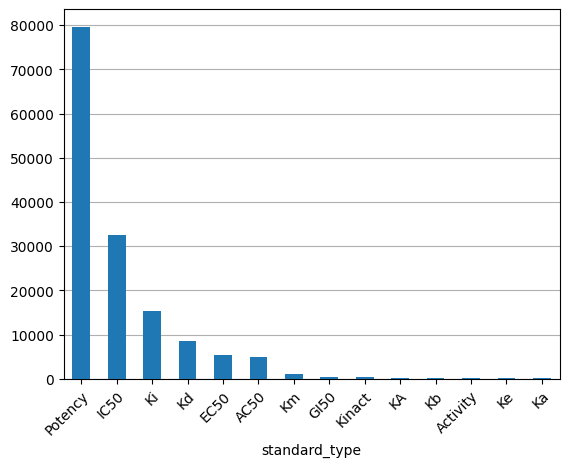

In [8]:
type_counts = queried_df["standard_type"].value_counts()
type_more_than_100 = type_counts[type_counts > 100]

type_more_than_100.plot.bar(zorder=3)
ax = plt.gca()
ax.set_xticklabels(
    ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
)
ax.grid(axis="y", zorder=0)
plt.show()

In [9]:
print(
    "Are all the assays reporting unique target - cpd interactions?",
    queried_df[["JUMP_ID", "type", "target_chembl_id"]].shape
    == queried_df[["JUMP_ID", "type", "target_chembl_id"]].drop_duplicates().shape,
)

np.testing.assert_array_equal(  # sanity check on the standard relation
    queried_df["relation"].values, queried_df["standard_relation"].values
)

queried_df = queried_df.drop(
    columns=["type", "relation", "units", "value", "standard_value", "type", "canonical_smiles", "description"]
)  # we'll use pchembl_values

# drop points with no pchembl_values:
no_pchembl_idxs = queried_df.query("pchembl_value.isna()").index
queried_df = queried_df.drop(index=no_pchembl_idxs).reset_index(drop=True)

# rename assay types since we're going to use pchembl_values
rename_dict = {
    "pAC50": "AC50",
    "pEC50": "EC50",
    "pIC50": "IC50",
    "pKi": "Ki",
    "pKd": "Kd",
    "Log Ki": "Ki",
    "Log IC50": "IC50",
    "Log EC50": "EC50",
}
queried_df = queried_df.assign(type=lambda x: x["standard_type"].replace(rename_dict))

# keep only the desired activity types
desired_types = ["IC50", "Potency", "Ki", "Kd", "AC50", "EC50"]
queried_df = queried_df.query("standard_type.isin(@desired_types)")

Are all the assays reporting unique target - cpd interactions? False


In [12]:
queried_df.to_csv("jump_chemSmiSW_chembl_data_cleaned.csv", index=False)

<Axes: xlabel='standard_type'>

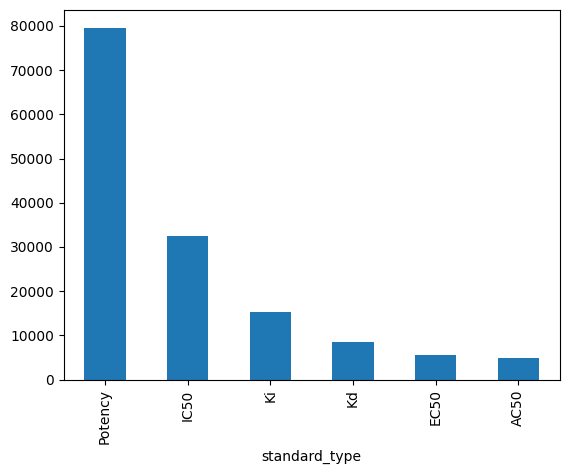

In [11]:
queried_df["standard_type"].value_counts().plot.bar()

# Merge the data

In [60]:
import functools
from scipy.stats import median_abs_deviation
from loguru import logger
import pandas as pd
import numpy as np


def find_repeated_indices_df(df: pd.DataFrame, columns: list) -> list:
    """Find repeated indices for given columns in a DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame to search for repeats.
        columns (list): List of column names to identify repeats across.

    Returns:
        list: A list of lists containing indices of repeated rows based on specified columns.
    """
    # Validate input
    if not all(col in df for col in columns):
        raise ValueError("One or more specified columns do not exist in the DataFrame.")

    # Concatenate values of specified columns into a single series
    concatenated_series = df[columns].astype(str).agg("-".join, axis=1)

    # Find duplicates using numpy operations
    def find_duplicate_index(series: pd.Series) -> list[list[int]]:
        arr = series.to_numpy()
        sidx = np.lexsort(arr.reshape(1, -1))
        sorted_series = series.iloc[sidx]
        sorted_arr = sorted_series.to_numpy()
        # Identify duplicates
        duplicates_mask = np.concatenate(
            ([False], sorted_arr[1:] == sorted_arr[:-1], [False])
        )
        idx = np.flatnonzero(duplicates_mask[1:] != duplicates_mask[:-1])
        # Extract original indices for duplicates
        sorted_indices = sorted_series.index.tolist()
        return [sorted_indices[i:j] for i, j in zip(idx[::2], idx[1::2] + 1)]

    final_repeat_idxs = find_duplicate_index(concatenated_series)
    return final_repeat_idxs


def merge_dataframes(dfs, id_cols):
    """
    Merge a list of DataFrames based on id_cols. Useful reference for merges:
    https://stackoverflow.com/questions/53645882/pandas-merging-101

    Args:
        dfs: List of DataFrames to be merged
        id_cols: List of columns to be used as keys for merging

    Returns:
        merged_df: Merged DataFrame
    """
    return functools.reduce(
        lambda left, right: pd.merge(left, right, on=id_cols, how="inner"), dfs
    )


def apply_func_grpd(grpd, func: callable, idcols: list, *cols: list) -> pd.DataFrame:
    """Apply a function to a list of columns (*cols) a grouped dataframe and
    merge the results based on id_cols.

    Args:
        grpd: grouped dataframe
        func: callable function to be applied
        idcols: list of columns to be used as index
    """
    results = []
    for col in cols:
        results.append(grpd[col].apply(func).reset_index().set_index(idcols).copy())
    return pd.concat(results, ignore_index=False, axis=1).reset_index()


def format_value(x):
    if isinstance(x, float):
        return f"{x:.4f}"
    elif isinstance(x, int):
        return str(x)
    else:
        return x


def aggr_val_series(series: pd.Series):
    return ";".join([format_value(x) for x in series])


def get_mad(values):
    if len(values) > 1:
        return median_abs_deviation(values)
    else:
        return np.nan


def assign_stats(df: pd.DataFrame, value_col="pchembl_value"):
    value_series = df[value_col].str.split(";").apply(lambda x: list(map(float, x)))
    # value_series = value_series.apply()
    new_cols = [
        f"{value_col}_mean",
        f"{value_col}_std",
        f"{value_col}_median",
        f"{value_col}_mad",
        "value_counts",
    ]
    values = [
        value_series.apply(np.mean),
        value_series.apply(np.std),
        value_series.apply(np.median),
        value_series.apply(get_mad),
        value_series.apply(lambda x: len(x)),
    ]
    for c, v in zip(new_cols, values):
        df[c] = v
    return df


def process_repeat_mols(
    df: pd.DataFrame, repeat_element_idxs: list, solve_strat: str = "keep"
) -> pd.DataFrame:
    """Process the dataframe according to repeated elements identified
    with the function `find_repeated_arr_from_series`. The standard criteria here
    will be that molecules with the same Fingerprint representation will be treated
    as a single entity, and will have their values aggregated. Upon aggregation, if the
    min & max values differ 1 or more log units, then those samples will be remioved
    from the dataset. Otherwise, values will be aggregated and a new column will be
    assigned, called `might_rancemic`. This column will be a boolean, indicating
    whether the molecule might be rancemic or not.

    Args:
        df: dataframe with the bioactivity data
        repeat_element_idxs: list of indices of repeated elements in the dataframe.
        solve_strat: strategy to solve the repeated elements. If 'drop', then both the
            points within >= 1 log unit difference will be dropped. If 'keep', then
            no values will be dropped.

    Returns:
        df: dataframe with the repeated elements processed.
    """
    df = df.copy()
    repeat_mapping = {}
    for idx in range(len(repeat_element_idxs)):
        for i in repeat_element_idxs[idx]:
            repeat_mapping[i] = idx
    df = df.assign(repeat_mapping=lambda x: x.index.map(repeat_mapping))
    repeat_subset = df.query("~repeat_mapping.isna()").assign(
        pchembl_value=lambda x: x.pchembl_value.astype(str)
    )
    numeric_activity = (
        # concatenate grouped values and convert to numeric arrays
        repeat_subset.groupby(["repeat_mapping"])["pchembl_value"]
        .apply(lambda x: ";".join(x))
        .str.split(";")
        .apply(lambda x: np.array(x).astype(float))
    )
    max_series = numeric_activity.apply(lambda x: np.max(x))
    min_series = numeric_activity.apply(lambda x: np.min(x))
    distance_series = max_series - min_series

    # Will drop the repeats with more than 1 log unit difference
    high_diff_repeats = np.where(distance_series >= 1)[0]
    points_dropped = len(repeat_subset["repeat_mapping"].isin(high_diff_repeats))
    logger.info(
        f"Found {len(high_diff_repeats)} repeats with more than 1 log unit difference."
    )
    logger.info(
        f"Maximum difference between min & max values: {np.max(distance_series)}"
    )
    if solve_strat == "drop":
        logger.info(f"{points_dropped} points will be removed from the dataset")

    id_cols = ["JUMP_ID", "repeat_mapping", "target_chembl_id"]
    multival_cols = [
        "standard_smiles",
        "pchembl_value",
        "assay_chembl_id",
        "assay_description",
        "activity_id",
        "assay_type",
        "standard_type",
        "confidence_score",
        "standard_relation",
        "target_organism",
        "molecule_chembl_id",
        "document_chembl_id",
        "assay_tissue",
        "assay_cell_type",
        "relationship_description",
        "variant_sequence",
        "indication_class",
        "max_phase",
        "oral",
        "prodrug",
        "withdrawn_flag",
    ]
    final_cols = id_cols + multival_cols
    grouped = repeat_subset.groupby(id_cols)
    updated_vals = apply_func_grpd(grouped, aggr_val_series, id_cols, *multival_cols)
    updated_df = assign_stats(updated_vals, value_col="pchembl_value").merge(
        df, on=id_cols, how="left"
    )
    rename_cols = {c: c.rstrip("_x") for c in updated_df.columns if c.endswith("_x")}
    todrop_cols = [c for c in updated_df.columns if c.endswith("_y")]
    updated_df = updated_df.drop(columns=todrop_cols).rename(columns=rename_cols)
    todrop_processed = updated_df["repeat_mapping"].isin(high_diff_repeats).index
    if solve_strat == "drop":
        updated_df = updated_df.drop(index=todrop_processed)
    # drop the repeats and concatenate with the filtered & updated values
    df = pd.concat(
        [
            df.drop(index=repeat_subset.index).assign(
                might_rancemic=lambda x: [False] * len(x)
            ),
            updated_df.assign(might_rancemic=lambda x: [True] * len(x)),
        ],
        ignore_index=True,
    )
    logger.info(f"Final number of points: {len(df)}")
    return df, final_cols


def assign_stats(df: pd.DataFrame, value_col="pchembl_value"):
    value_series = (
        df[value_col].astype(str).str.split(";").apply(lambda x: list(map(float, x)))
    )
    # value_series = value_series.apply()
    new_cols = [
        f"{value_col}_mean",
        f"{value_col}_std",
        f"{value_col}_median",
        f"{value_col}_mad",
        "value_counts",
    ]
    values = [
        value_series.apply(np.mean),
        value_series.apply(np.std),
        value_series.apply(np.median),
        value_series.apply(get_mad),
        value_series.apply(lambda x: len(x)),
    ]
    for c, v in zip(new_cols, values):
        df[c] = v
    return df

In [61]:
queried_df["standard_type"].unique()

array(['Kd', 'IC50', 'Ki', 'EC50', 'Potency', 'AC50'], dtype=object)

In [63]:
groups = [["Potency"], ["Kd", "Ki"], ["IC50", "AC50", "EC50"], ["IC50"]]

for group in groups:
    subset = queried_df.query("standard_type.isin(@group)")
    # assert that the standard_type is in all the columns I have:
    assert np.isin(subset["standard_type"].unique(), np.array(group)).all()
    repeats_idxs = find_repeated_indices_df(subset, ["JUMP_ID", "target_chembl_id"])
    final_data, final_cols = process_repeat_mols(
        subset, repeats_idxs, solve_strat="keep"
    )
    final_data = final_data[final_cols].drop_duplicates().reset_index(drop=True)
    final_data = assign_stats(final_data)
    activity_annotation = "_".join(group)
    final_data.to_csv(
        f"jump_chemSmiSW_chembl_data_cleaned_{activity_annotation}.csv", index=False
    )

2024-03-20 16:53:20.115 | INFO     | __main__:process_repeat_mols:163 - Found 905 repeats with more than 1 log unit difference.
2024-03-20 16:53:20.121 | INFO     | __main__:process_repeat_mols:166 - Maximum difference between min & max values: 5.200000286102295
2024-03-20 16:53:27.695 | INFO     | __main__:process_repeat_mols:218 - Final number of points: 79631
2024-03-20 16:53:35.830 | INFO     | __main__:process_repeat_mols:163 - Found 1283 repeats with more than 1 log unit difference.
2024-03-20 16:53:35.833 | INFO     | __main__:process_repeat_mols:166 - Maximum difference between min & max values: 6.250000476837158
2024-03-20 16:53:38.294 | INFO     | __main__:process_repeat_mols:218 - Final number of points: 23920
2024-03-20 16:53:40.835 | INFO     | __main__:process_repeat_mols:163 - Found 2290 repeats with more than 1 log unit difference.
2024-03-20 16:53:40.836 | INFO     | __main__:process_repeat_mols:166 - Maximum difference between min & max values: 6.210000038146973
2024-

In [50]:
mixed_assays = final_data["standard_type"].apply(
    lambda x: np.unique(x.split(";")).shape[0]
)
final_data[mixed_assays > 1]

,JUMP_ID,repeat_mapping,target_chembl_id,standard_smiles,pchembl_value,assay_chembl_id,assay_description,activity_id,assay_type,standard_type,...,document_chembl_id,assay_tissue,assay_cell_type,relationship_description,variant_sequence,indication_class,max_phase,oral,prodrug,withdrawn_flag


# Get protein info

In [17]:
from UniProtMapper import ProtMapper

mapper = ProtMapper()

fields = ["accession", "organism_name", "gene_names", "go_p", "go_c", "go_f"]
result, failed = mapper.get(ids=chembl_targets, from_db="ChEMBL", fields=fields)

Retrying in 3s
Fetched: 477 / 503
Retrying in 3s
Fetched: 442 / 510
Retrying in 3s
Fetched: 489 / 535
Retrying in 3s
Fetched: 432 / 504
Retrying in 3s
Fetched: 432 / 502
Retrying in 3s
Fetched: 444 / 508
Retrying in 3s
Fetched: 481 / 558
Retrying in 3s
Fetched: 159 / 178


In [19]:
result.to_csv("chembl_targets_info.csv", index=False)

In [20]:
failed

['CHEMBL1907600',
 'CHEMBL1293303',
 'CHEMBL6110',
 'CHEMBL2150835',
 'CHEMBL1795092',
 'CHEMBL1293311',
 'CHEMBL1293251',
 'CHEMBL1795086',
 'CHEMBL4106139',
 'CHEMBL2111389',
 'CHEMBL1907605',
 'CHEMBL3403',
 'CHEMBL5077',
 'CHEMBL3885546',
 'CHEMBL1907601',
 'CHEMBL2111455',
 'CHEMBL2111448',
 'CHEMBL1907602',
 'CHEMBL3038469',
 'CHEMBL3038475',
 'CHEMBL3038472',
 'CHEMBL304',
 'CHEMBL6184',
 'CHEMBL2094108',
 'CHEMBL2366517',
 'CHEMBL3137286',
 'CHEMBL2095183',
 'CHEMBL3797017',
 'CHEMBL2111367',
 'CHEMBL2111432',
 'CHEMBL1293247',
 'CHEMBL4295521',
 'CHEMBL1741163',
 'CHEMBL1075045',
 'CHEMBL3885582',
 'CHEMBL1907589',
 'CHEMBL1907595',
 'CHEMBL2109234',
 'CHEMBL1907590',
 'CHEMBL2366408',
 'CHEMBL1293265',
 'CHEMBL4523626',
 'CHEMBL1293307',
 'CHEMBL5471',
 'CHEMBL3038491',
 'CHEMBL3301391',
 'CHEMBL3301390',
 'CHEMBL3301392',
 'CHEMBL3430899',
 'CHEMBL1741212',
 'CHEMBL6131',
 'CHEMBL5157',
 'CHEMBL5798',
 'CHEMBL3562178',
 'CHEMBL3885669',
 'CHEMBL5042',
 'CHEMBL5219',
 'CHEMBL

## Investigate parent / active compounds

In [42]:
print("test if we have all the active ids")
active_ids_bool = np.isin(
    queried_df["hierarchy_active_id"].unique(),
    queried_df["molecule_chembl_id"].unique(),
)
print(active_ids_bool.all())
print("test if we have all the parent ids")
parent_ids_bool = np.isin(
    queried_df["hierarchy_parent_id"].unique(),
    queried_df["molecule_chembl_id"].unique(),
)
print(parent_ids_bool.all())

test if we have all the active ids
False
test if we have all the parent ids
False


In [43]:
active_ids = np.compress(~active_ids_bool, queried_df["hierarchy_active_id"].unique())
parent_ids = np.compress(~parent_ids_bool, queried_df["hierarchy_parent_id"].unique())

print("active ids not in the queried_df:")
print(len(active_ids))
print("parent ids not in the queried_df:")
print(len(parent_ids))

active ids not in the queried_df:
568
parent ids not in the queried_df:
535


In [44]:
unique_missing_ids = np.unique(parent_ids.tolist() + active_ids.tolist()).tolist()

In [46]:
from CompoundMapper.chembl import molecule_info_from_chembl, compounds_api

act_parent_df = molecule_info_from_chembl(unique_missing_ids)

# compounds_api.filter(molecule_chembl_id__in=unique_missing_ids).only(
#     "molecule_hierarchy",
#     "molecule_structures",
#     "chemical_probes",
#     "chirality",
#     "oral",
#     "prodrug",
#     "max_phase",
#     "therapeutical_flag",
#     "withdrawn_flag",
#     "indication_class",
# )

2024-03-11 12:20:04.239 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1179998
2024-03-11 12:20:04.245 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1219
2024-03-11 12:20:04.254 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1616335
2024-03-11 12:20:04.255 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1616537
2024-03-11 12:20:04.256 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1616581
2024-03-11 12:20:04.256 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1616652
2024-03-11 12:20:04.256 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy infor

2024-03-11 12:20:04.327 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1622668
2024-03-11 12:20:04.327 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1622677
2024-03-11 12:20:04.328 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1622684
2024-03-11 12:20:04.331 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1622695
2024-03-11 12:20:04.332 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1622721
2024-03-11 12:20:04.332 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy information found for molecule CHEMBL1622732
2024-03-11 12:20:04.332 | WARNING  | CompoundMapper.chembl:molecule_info_from_chembl:113 - No hierarchy in

In [63]:
different = filtered_df.query("JUMP_ID == 'JCP2022_000062'")[
    "hierarchy_active_id"
].values.tolist()

In [91]:
filtered_weird_df = filtered_df.query(
    "hierarchy_active_id.isin(@unique_missing_ids) | hierarchy_parent_id.isin(@unique_missing_ids)"
)
filtered_weird_df

,JUMP_ID,molecule_chembl_id,canonical_smiles,hierarchy_active_id,hierarchy_parent_id
178,JCP2022_000135,CHEMBL1095292,CC[N+](C)(C)Cc1ccccc1Br.Cc1ccc(S(=O)(=O)[O-])cc1,CHEMBL1199080,CHEMBL1199080
367,JCP2022_000442,CHEMBL1578147,CC(NCc1ccc2c(c1)OCO2)C(=O)NC1CCCc2ccccc21.O=C(...,CHEMBL1626079,CHEMBL1626079
437,JCP2022_000501,CHEMBL1306613,Cl.O=S(=O)(CCC1CCCCN1)c1ccccc1,CHEMBL1616581,CHEMBL1616581
1094,JCP2022_000856,CHEMBL1532760,NC1C[C@H]1c1ccccc1.O=S(=O)(O)O,CHEMBL1623519,CHEMBL1623519
1223,JCP2022_000870,CHEMBL500826,O=C([O-])CF.[Na+],CHEMBL509273,CHEMBL509273
...,...,...,...,...,...
117253,JCP2022_114929,CHEMBL1585088,Cl.OCCNCc1cc(Br)ccc1OCc1ccccc1,CHEMBL1625370,CHEMBL1625370
117880,JCP2022_115404,CHEMBL1532190,Br.Cc1nn2cc(-c3ccc(Cl)cc3)nc2s1,CHEMBL1623623,CHEMBL1623623
118017,JCP2022_115631,CHEMBL1452657,Br.CN1[C@@H]2CC[C@H]1C[C@@H](OC(=O)C(O)c1ccccc...,CHEMBL1618018,CHEMBL1618018
118124,JCP2022_115780,CHEMBL1505066,CCn1c2ccccc2c2cc(NC(=O)CNC)ccc21.O=C(O)C(=O)O,CHEMBL1622261,CHEMBL1622261


In [95]:
# for row in filtered_weird_df.iterrows():
#     in_dataset = row[1]["molecule_chembl_id"]
#     outside_dataset = np.unique(
#         row[1]["hierarchy_active_id"], row[1]["hierarchy_parent_id"]
#     )[0].tolist()
#     smi1 = filtered_df.query("molecule_chembl_id == @in_dataset")[
#         "canonical_smiles"
#     ].values[0]
#     smi2 = act_parent_df.query("molecule_chembl_id.isin(@outside_dataset)")[
#         "canonical_smiles"
#     ].values[0]

#     img = smis_to_fig(
#         [smi1, smi2], legends=["JUMP_cpd"].extend(["hierarchy_cpd"] * len(smi2))
#     )
#     display(img)

In [77]:
non_unique_jumps = {}
for _id in unique_missing_ids:
    unique_jumps = queried_df.query(
        f"hierarchy_active_id == '{_id}' | hierarchy_parent_id == '{_id}'"
    )["JUMP_ID"].unique()
    if unique_jumps.size > 1:
        print(f"{_id} is in more than one jump")
        print(unique_jumps)
        non_unique_jumps.update(
            {
                _id: {
                    "jump_ids": unique_jumps.tolist(),
                    "is_parent": _id in parent_ids,
                    "is_active": _id in active_ids,
                }
            }
        )

CHEMBL101263 is in more than one jump
['JCP2022_045146' 'JCP2022_074123']
CHEMBL101265 is in more than one jump
['JCP2022_021032' 'JCP2022_086879']
CHEMBL1098319 is in more than one jump
['JCP2022_085702' 'JCP2022_104892' 'JCP2022_114396']
CHEMBL112322 is in more than one jump
['JCP2022_032630' 'JCP2022_106493']


CHEMBL1381 is in more than one jump
['JCP2022_076383' 'JCP2022_088138']
CHEMBL15976 is in more than one jump
['JCP2022_048609' 'JCP2022_056537']
CHEMBL1616045 is in more than one jump
['JCP2022_038454' 'JCP2022_063457']
CHEMBL1616388 is in more than one jump
['JCP2022_038239' 'JCP2022_073161']
CHEMBL1620208 is in more than one jump
['JCP2022_026499' 'JCP2022_073164']
CHEMBL1620698 is in more than one jump
['JCP2022_068588' 'JCP2022_068589']
CHEMBL1621581 is in more than one jump
['JCP2022_027388' 'JCP2022_108998']
CHEMBL1621642 is in more than one jump
['JCP2022_028578' 'JCP2022_079776']
CHEMBL1622261 is in more than one jump
['JCP2022_080260' 'JCP2022_115780']
CHEMBL1623623 is in more than one jump
['JCP2022_068009' 'JCP2022_074851' 'JCP2022_115404']
CHEMBL1623900 is in more than one jump
['JCP2022_026499' 'JCP2022_073164']
CHEMBL1625829 is in more than one jump
['JCP2022_005161' 'JCP2022_091614']
CHEMBL1625974 is in more than one jump
['JCP2022_048908' 'JCP2022_051923']
CHEMBL1794685

## Investigate salts

In [6]:
chem_struc_only_df = queried_df[
    [
        "JUMP_ID",
        "molecule_chembl_id",
        "canonical_smiles",
        "hierarchy_active_id",
        "hierarchy_parent_id",
    ]
].drop_duplicates()

In [12]:
# smis_to_fig(
#     [
#         chem_struc_only_df[
#             chem_struc_only_df["canonical_smiles"].str.contains(".", regex=False)
#         ]["canonical_smiles"]
#         .str.split(".")
#         .explode()
#         .value_counts()[:50]
#         .index.tolist()
#     ],
#     molsPerRow=10,
# )

TypeError: No registered converter was able to produce a C++ rvalue of type std::basic_string<wchar_t, std::char_traits<wchar_t>, std::allocator<wchar_t> > from this Python object of type list

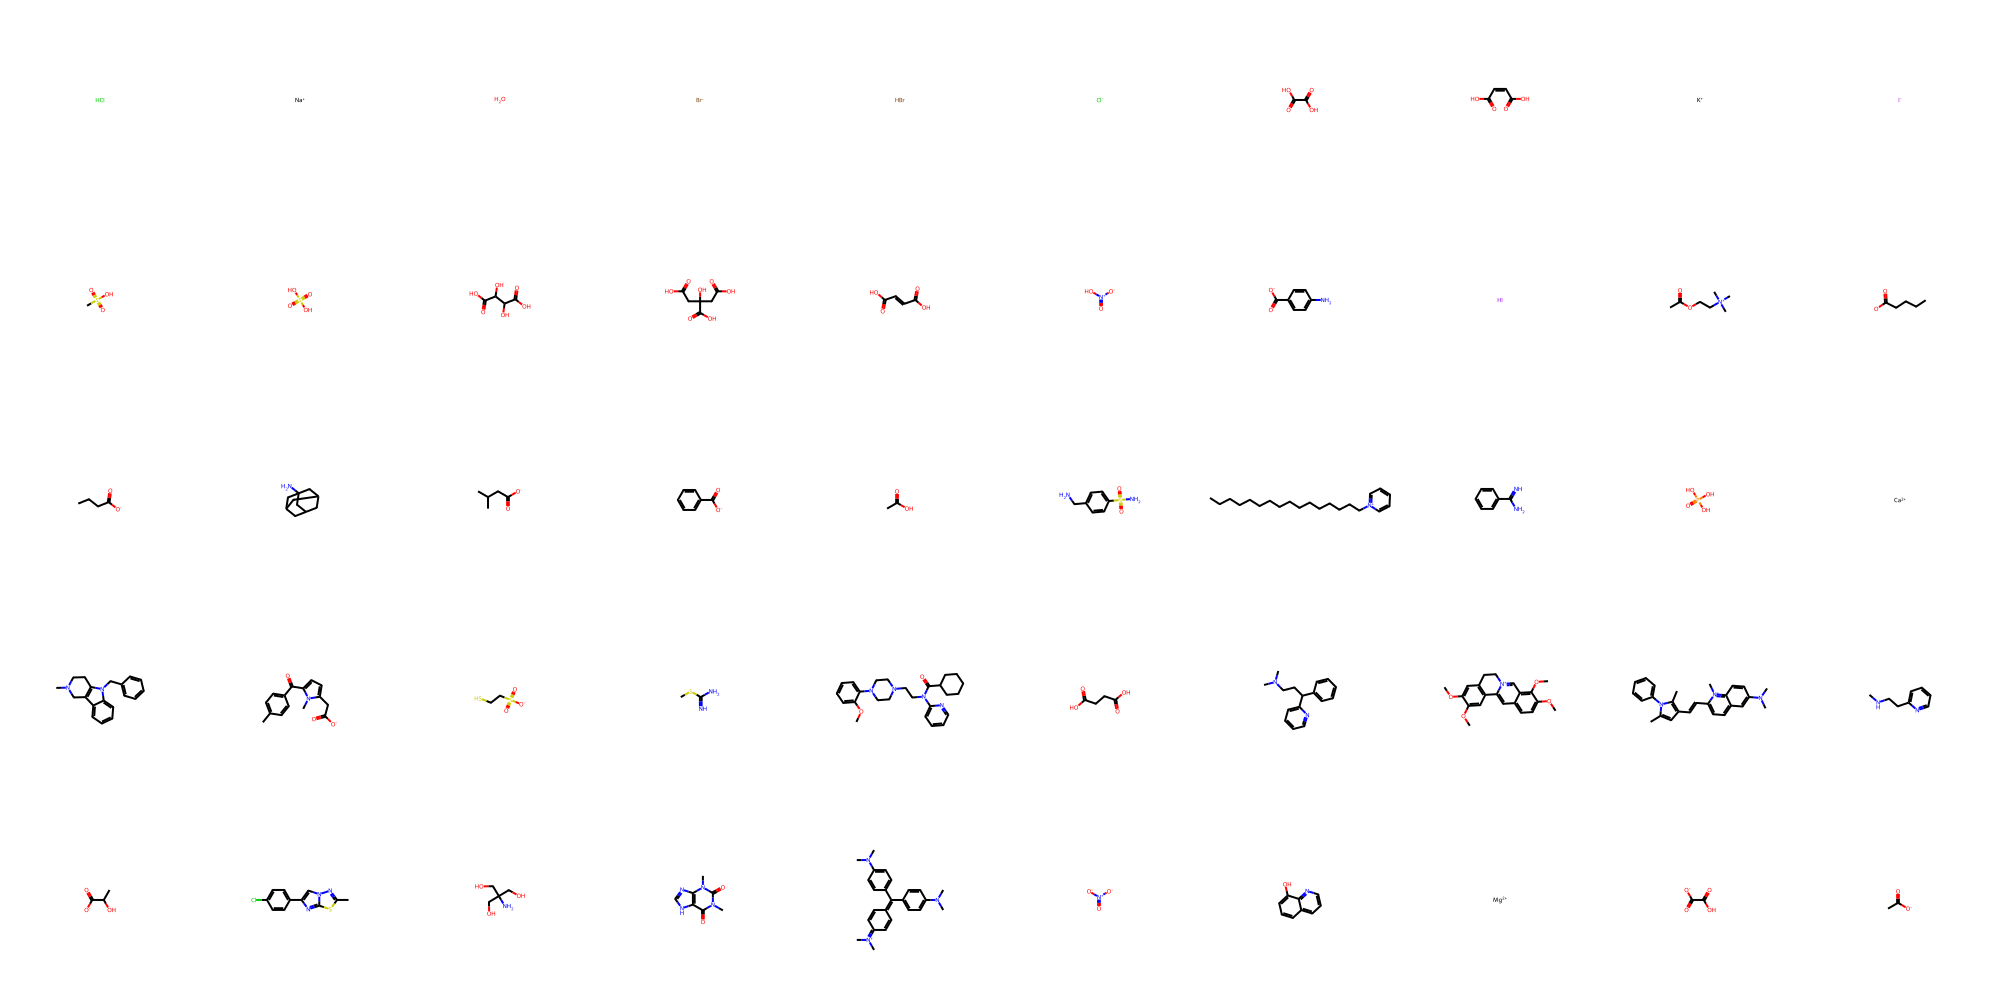

In [13]:
# define a list of common salts and other mixtures not flagged by ChEMBL structure pipeline
MIXTURE_REGEX = re.compile(
    r"^("
    r"Na\+?|Cl\-?|Br\-?|K\+?|F\-?|I\-?|Ca\+{2}?|Mg\+{2}?|Zn\+{2}?|OH\-?|"
    r"\[Na\+\]?|\[K\+\]?|\[Cl-\]?|\[Br-\]?|\[I-\]?|\[Zn\+2\]?|"
    r"CCCC\(=O\)\[O-\]|"  # Butyrate
    r"CCCCC\(=O\)\[O-\]|"  # Pentanoate
    r"C1=CC=C\(C=C1\)C\(=O\)\[O-\]|"  # Benzoate
    r"\[O-\]\[Cl\+3\]\(\[O-\]\)\(\[O-\]\)\[O-\]|"  # Perchlorate
    r"C1=CC=NC=C1|"  # Pyridine
    r"O=CN\(C\)C|"  # N,N-Dimethylformamide
    r"\[NO\]|"  # Nitric oxide, corrected
    r"c1ccc\(\[B-\]\(c2ccccc2\)\(c2ccccc2\)c2ccccc2\)cc1|"  # Tetraphenylborate
    r"^O$|^N$"  # Match full strings for O and N
    r")$"
)



def clean_mixtures(smi):
    smiles = np.unique(smi.split(".")).tolist()
    if len(smiles) == 1:
        return smiles[0]
    else:
        no_salt_smiles = [MIXTURE_REGEX.sub("", smi) for smi in smiles]
        no_salt_smiles = [smi for smi in no_salt_smiles if smi]
        if len(no_salt_smiles) == 0:
            return "."  # in this case wil drop the smiles
        return ".".join(no_salt_smiles)


smis_to_fig(
    chem_struc_only_df[
        chem_struc_only_df["canonical_smiles"].str.contains(".", regex=False)
    ]["canonical_smiles"]
    .str.split(".")
    .explode()
    .value_counts()[:50]
    .index.tolist(),
    molsPerRow=10,
)

In [38]:
from chemFilters.chem.standardizers import ChemStandardizer

stdzer = ChemStandardizer(from_smi=True)

std_smiles = stdzer(
    chem_struc_only_df[
        chem_struc_only_df["canonical_smiles"].str.contains(".", regex=False)
    ]["canonical_smiles"].values.tolist()
)

[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Normalizer
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Normalizer
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Normalizer
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Normalizer
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Normalizer
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Normalizer
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Normalizer
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Normalizer
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51:40] Running Uncharger
[15:51

In [44]:
# pd.Series(std_smiles).str.contains(".", regex=False).sum()
pd.Series(std_smiles)[pd.Series(std_smiles).str.contains(".", regex=False)].apply(
    lambda x: clean_mixtures(x)
).str.contains(".", regex=False).sum()
# chem_struc_only_df["canonical_smiles"].str.contains(".", regex=False).sum()

20

In [39]:
pd.Series(std_smiles)[pd.Series(std_smiles).str.contains(".", regex=False)].str.split(
    "."
).explode().value_counts()[:40]

[Na+]                                                                           46
[K+]                                                                            11
CCCC(=O)[O-]                                                                     6
CCCCC(=O)[O-]                                                                    6
O=C([O-])c1ccccc1                                                                4
CC(=O)[O-]                                                                       3
CC(O)C(=O)[O-]                                                                   3
O=C([O-])C[C@H](O)C(=O)[O-]                                                      3
O=C([O-])CC(O)C(=O)[O-]                                                          3
[Mg+2]                                                                           2
O=C([O-])C(=O)[O-]                                                               2
CN(C)c1ccc(C(=C2C=CC(=[N+](C)C)C=C2)c2ccc(N(C)C)cc2)cc1                          2
O=C(

In [28]:
from chembl_structure_pipeline import get_parent_mol

parent = get_parent_mol(Chem.MolFromSmiles(std_smiles[0]), verbose=True)
print(parent)
res = Chem.MolToSmiles(parent[0])
print(res)

matched salt Tosylate
(<rdkit.Chem.rdchem.Mol object at 0x7fbf5d543450>, False)
CC[N+](C)(C)Cc1ccccc1Br


[14:47:07] Running Uncharger
[14:47:07] Running Uncharger


In [16]:


std_smiles

['CC[N+](C)(C)Cc1ccccc1Br.Cc1ccc(S(=O)(=O)[O-])cc1',
 'CC(NCc1ccc2c(c1)OCO2)C(=O)NC1CCCc2ccccc21.O=C(O)C(=O)O',
 'Cl.O=S(=O)(CCC1CCCCN1)c1ccccc1',
 'O=C(O)/C=C\\C(=O)O.O=C(c1ccc(OCCCc2c[nH]cn2)cc1)C1CC1',
 'O=C(O)/C=C/C(=O)O.O=C(c1ccc(OCCCc2c[nH]cn2)cc1)C1CC1',
 'COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2.Cl',
 'COc1cc2c(cc1OC)C(=O)[C@@H](CC1CCN(Cc3ccccc3)CC1)C2.Cl',
 'COc1cc2c(cc1OC)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2.Cl.O',
 'COc1cc2c(cc1OC)C(=O)[C@H](CC1CCN(Cc3ccccc3)CC1)C2.Cl',
 'Cl.NC1CC1c1ccccc1',
 'Cl.N[C@@H]1C[C@H]1c1ccccc1',
 'NC1C[C@H]1c1ccccc1.O=S(=O)(O)O',
 'N[C@@H]1C[C@H]1c1ccccc1.N[C@H]1C[C@@H]1c1ccccc1',
 'O=C([O-])CF.[Na+]',
 'CCC(=O)[O-].[Na+]',
 'COc1cc2c(cc1OC)[C@@H]1Cc3ccc(OC)c(OC)c3CN1CC2.Cl',
 'COc1cc2c(cc1OC)C1Cc3ccc(OC)c(OC)c3CN1CC2.Cl',
 'Br.O=[N+]([O-])c1ccc(CSC2=NCCN2)cc1',
 'Clc1ccc(CSC(Cn2ccnc2)c2ccc(Cl)cc2Cl)cc1.O=[N+]([O-])O',
 'Clc1ccc(COC(Cn2ccnc2)c2ccc(Cl)cc2Cl)cc1.O=[N+]([O-])O',
 'CCN(CC)CCOC(=O)C(c1ccccc1)C1CCCCC1.Cl',
 'Cl.Fc1ccc([C@@H]2CCNC[C@H]2COc

In [131]:
# smis_to_fig(

# .explode()
# .value_counts()[:50]
# .index.tolist(),
# molsPerRow=10,
# )
# chem_struc_only_df[
#     chem_struc_only_df["canonical_smiles"].str.contains(".", regex=False)
# ]["canonical_smiles"].apply(clean_mixtures).str.contains(".", regex=False)

178        True
367       False
437       False
439       False
453       False
          ...  
118875    False
119021    False
119022     True
119026     True
119157    False
Name: canonical_smiles, Length: 1154, dtype: bool

In [159]:
chem_struc_only_df[
    chem_struc_only_df["canonical_smiles"].str.contains(".", regex=False)
]["canonical_smiles"].tolist()[2]

'Cl.O=S(=O)(CCC1CCCCN1)c1ccccc1'

In [180]:
matched_salts = []
for smiles in chem_struc_only_df[
    chem_struc_only_df["canonical_smiles"].str.contains(".", regex=False)
]["canonical_smiles"]:
    split_smi = smiles.split(".")
    for smi in split_smi:
        found = MIXTURE_REGEX.findall(smi)
        if found:
            matched_salts.append(found)

In [191]:
_match = MIXTURE_REGEX.search("O=C(O)/C=C\\C(=O)O")
if _match:
    # Iterate over the group dictionary
    for name, value in _match.groupdict().items():
        if value:
            print(f"Matched {name}: {value}")

In [190]:
_match.

'O=C(O)/C=C\\C(=O)O'

In [172]:
(
    chem_struc_only_df[
        chem_struc_only_df["canonical_smiles"].str.contains(".", regex=False)
    ]["canonical_smiles"]
    .str.split(".")
    .explode()
    .value_counts()[:50]
    .index.tolist()
)

['Cl',
 '[Na+]',
 'O',
 '[Br-]',
 'Br',
 '[Cl-]',
 'O=C(O)C(=O)O',
 'O=C(O)/C=C\\C(=O)O',
 '[K+]',
 '[I-]',
 'CS(=O)(=O)O',
 'O=S(=O)(O)O',
 'O=C(O)C(O)C(O)C(=O)O',
 'O=C(O)CC(O)(CC(=O)O)C(=O)O',
 'O=C(O)/C=C/C(=O)O',
 'O=[N+]([O-])O',
 'Nc1ccc(C(=O)[O-])cc1',
 'I',
 'CC(=O)OCC[N+](C)(C)C',
 'CCCCC(=O)[O-]',
 'CCCC(=O)[O-]',
 'NC12CC3CC(CC(C3)C1)C2',
 'CC(C)CC(=O)[O-]',
 'O=C([O-])c1ccccc1',
 'CC(=O)O',
 'NCc1ccc(S(N)(=O)=O)cc1',
 'CCCCCCCCCCCCCCCC[n+]1ccccc1',
 'N=C(N)c1ccccc1',
 'O=P(O)(O)O',
 '[Ca+2]',
 'CN1CCc2c(c3ccccc3n2Cc2ccccc2)C1',
 'Cc1ccc(C(=O)c2ccc(CC(=O)[O-])n2C)cc1',
 'O=S(=O)([O-])CCS',
 'CSC(=N)N',
 'COc1ccccc1N1CCN(CCN(C(=O)C2CCCCC2)c2ccccn2)CC1',
 'O=C(O)CCC(=O)O',
 'CN(C)CCC(c1ccccc1)c1ccccn1',
 'COc1cc2c(cc1OC)-c1cc3ccc(OC)c(OC)c3c[n+]1CC2',
 'Cc1cc(/C=C/c2ccc3cc(N(C)C)ccc3[n+]2C)c(C)n1-c1ccccc1',
 'CNCCc1ccccn1',
 'CC(O)C(=O)[O-]',
 'Cc1nn2cc(-c3ccc(Cl)cc3)nc2s1',
 'NC(CO)(CO)CO',
 'Cn1c(=O)c2[nH]cnc2n(C)c1=O',
 'CN(C)c1ccc(C(=C2C=CC(=[N+](C)C)C=C2)c2ccc(N(C)C)cc2)

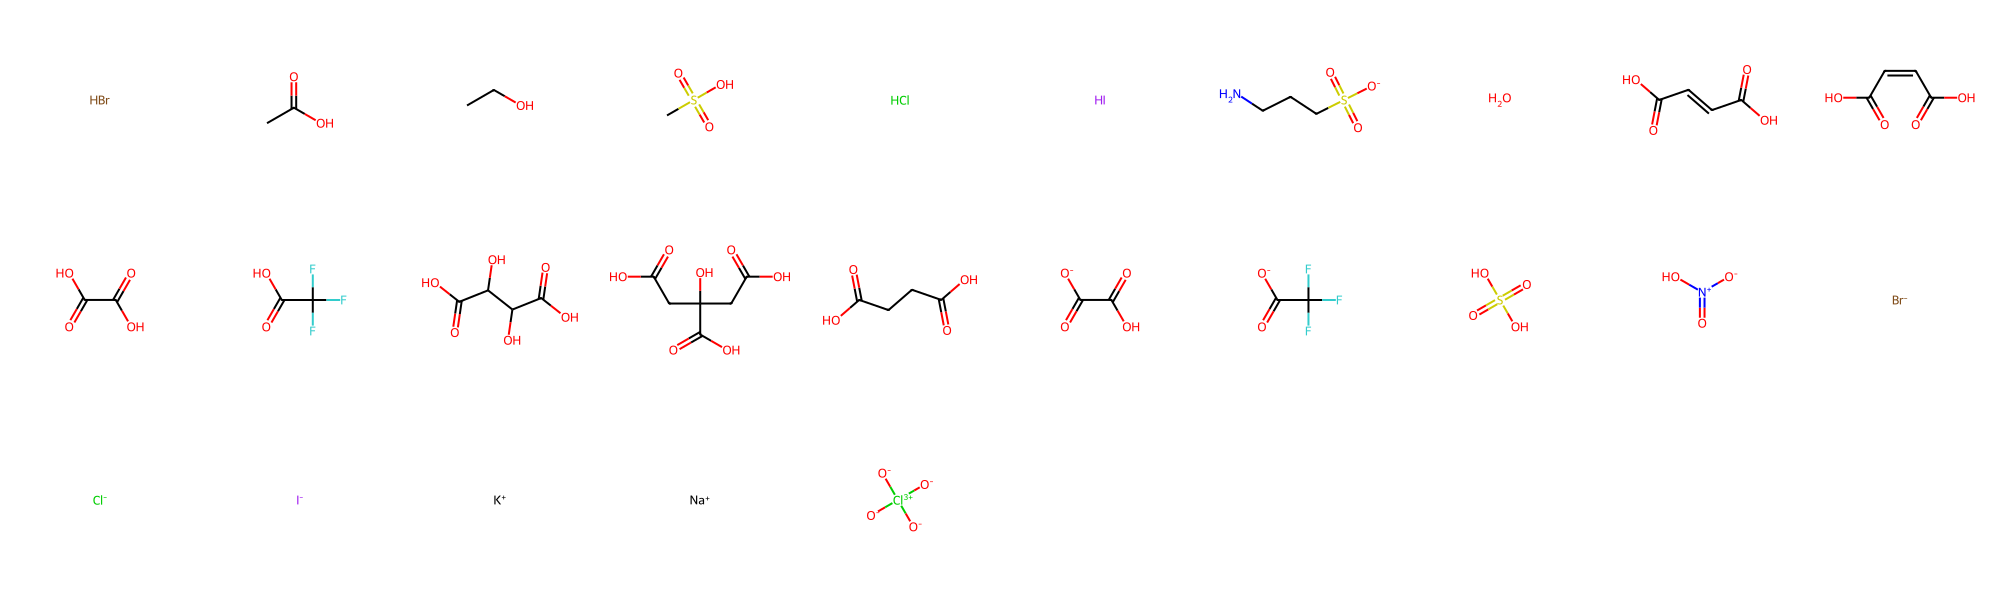

In [175]:
smis_to_fig(np.unique(matched_salts).tolist(), molsPerRow=10)

In [164]:
smi

'.'